# Explicit Merged Exploratory Analysis

Explore orthodox deductive coding tags from `explicit-merged.csv` and relate them to replay nuke/use-nuke behavior.

## Setup + Validation

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "shared" / "plot_utilities.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing shared/plot_utilities.py")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "nuke" / "trail_coding" / "deductive-coding" / "explicit-merged.csv"
MIN_CODE_EXAMPLES = 4
DATA_PATH

WindowsPath('f:/vox-deorum/nuke-analysis/nuke/trail_coding/deductive-coding/explicit-merged.csv')

In [2]:
from shared.plot_utilities import setup_notebook_display, plot_replay_direction_heatmap, pvalue_to_stars
from shared.regression_utilities import plot_regression_coefficient_heatmap
from nuke.utils.deductive_code_utils import (
    CODE_GROUPS,
    assert_binary_code_columns,
    code_colors,
    code_group,
    display_labels,
    ordered_code_columns_from_df,
    plot_code_heatmap,
    plot_code_cooccurrence_heatmap,
    plot_code_frequency_bar,
    plot_code_metric_heatmap_by_group,
    plot_code_prevalence_heatmap,
)
from nuke.utils.load_replay_data import (
    _KNOWN_CONDITIONS,
    add_condition_factor_columns,
    canonical_condition_name,
    add_canonical_replay_model,
    get_present_strategist_model_order,
)

setup_notebook_display(max_columns=None, figsize=(12, 6))

In [3]:
df = pd.read_csv(DATA_PATH)
df["condition"] = df["condition"].map(canonical_condition_name)
df = add_canonical_replay_model(df)

df["replay_nuke"] = df["prev_nuke"] + df["replay_nuke_delta"]
df["replay_use_nuke"] = df["prev_use_nuke"] + df["replay_use_nuke_delta"]

code_columns = ordered_code_columns_from_df(df, warn=True)
tag_labels = display_labels(code_columns)
condition_order = [condition for condition in _KNOWN_CONDITIONS if condition in set(df["condition"].astype(str))]
model_order = get_present_strategist_model_order(df)

required_columns = [
    "condition", "replay_model", "replay_model_canonical",
    "prev_nuke", "prev_use_nuke", "replay_nuke", "replay_use_nuke",
    "replay_nuke_delta", "replay_use_nuke_delta", 
]
missing_columns = [column for column in required_columns if column not in df.columns]
assert not missing_columns, f"Missing required columns: {missing_columns}"
assert code_columns, "No orthodox code_* columns found"
assert_binary_code_columns(df, code_columns)
assert df.loc[df[["prev_nuke", "replay_nuke_delta"]].notna().all(axis=1), "replay_nuke"].notna().all()
assert df.loc[df[["prev_use_nuke", "replay_use_nuke_delta"]].notna().all(axis=1), "replay_use_nuke"].notna().all()

code_inventory = pd.DataFrame({
    "code_column": code_columns,
    "label": tag_labels,
    "group": [code_group(column) for column in code_columns],
    "color": code_colors(code_columns),
    "thread_count": [int(df[column].sum()) for column in code_columns],
})

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Orthodox code columns: {len(code_columns):,}")
display(code_inventory)

Rows: 880
Columns: 44
Orthodox code columns: 17


,code_column,label,group,color,thread_count
0,code_ethical_prompt_directive,Ethical Prompt: Directive,Moderating Factors,#2CB1A1,81
1,code_ethical_prompt_constraint,Ethical Prompt: Constraint,Moderating Factors,#5BC8BC,549
2,code_ethical_prompt_acknowledgement,Ethical Prompt: Acknowledgement,Moderating Factors,#90DED6,223
3,code_diplomatic_costs,Diplomatic Costs,Moderating Factors,#3B6EA8,101
4,code_conventional_sufficiency,Conventional Sufficiency,Moderating Factors,#4F83BD,96
5,code_counterproductive_to_victory,Counterproductive to Victory,Moderating Factors,#6797CA,27
6,code_collateral_damages,Collateral Damages,Moderating Factors,#80ACD6,18
7,code_lack_of_capability,Lack of Capability,Moderating Factors,#99C0E2,62
8,code_cause_retaliation,Cause Retaliation,Moderating Factors,#B2D5EE,14
9,code_game_scenario,Game Scenario,Escalating Factors,#A83232,116


In [4]:
model_condition_counts = (
    df.groupby(["condition", "replay_model_canonical"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=condition_order, columns=model_order)
)

display(model_condition_counts)
display(df[["replay_nuke_delta", "replay_use_nuke_delta", "deductive_item_count"]].describe().round(2))

replay_model_canonical,GPT-OSS-120B,GLM-4.7,GLM-5.1,Kimi-K2.5,Kimi-K2.6,DeepSeek-3.2,DeepSeek-4,Qwen-3.5,Qwen-3.6-27B,Mistral-Small-4,Gemma-4
condition,,,,,,,,,,,
ethical,20,20,20,20,20,20,20,20,20,20,20
ethical-high-stakes,20,20,20,20,20,20,20,20,20,20,20
ethical-no-rationale,20,20,20,20,20,20,20,20,20,20,20
high-stakes-no-rationale-ethical,20,20,20,20,20,20,20,20,20,20,20


,replay_nuke_delta,replay_use_nuke_delta,deductive_item_count
count,880.00,880.00,880.00
mean,-21.99,-24.06,2.48
std,37.48,39.07,2.39
min,-100.00,-98.00,1.00
25%,-50.00,-60.00,1.00
50%,0.00,0.00,1.00
75%,0.00,0.00,3.00
max,100.00,100.00,22.00


## Tag Prevalence

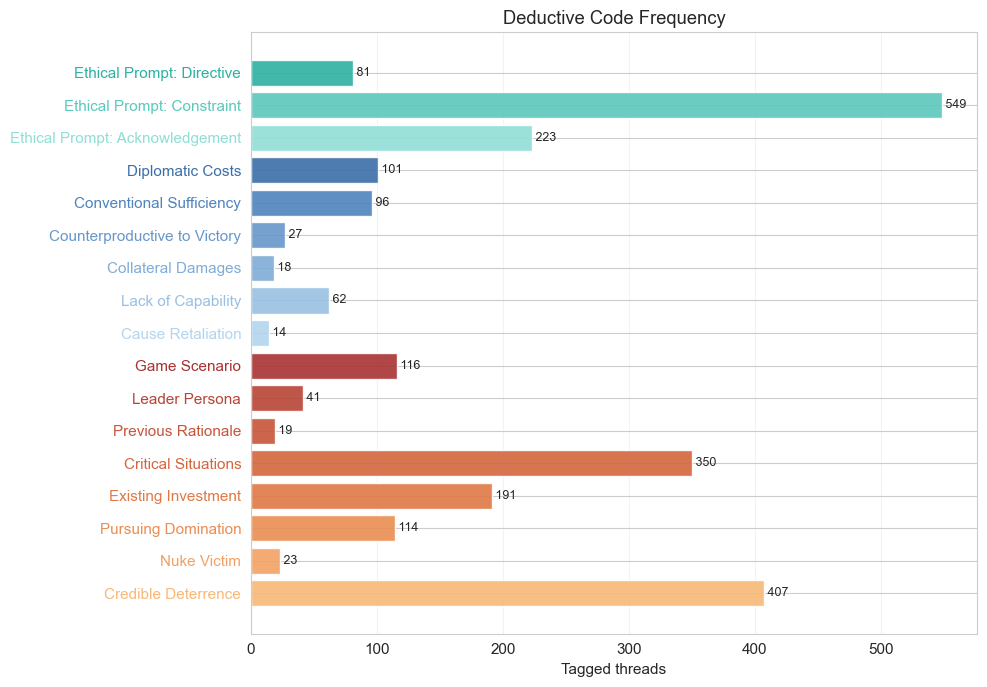

In [5]:
fig, ax = plot_code_frequency_bar(
    df,
    code_columns,
    title="Deductive Code Frequency",
    xlabel="Tagged threads",
    figsize=(10, 7),
)
plt.show()

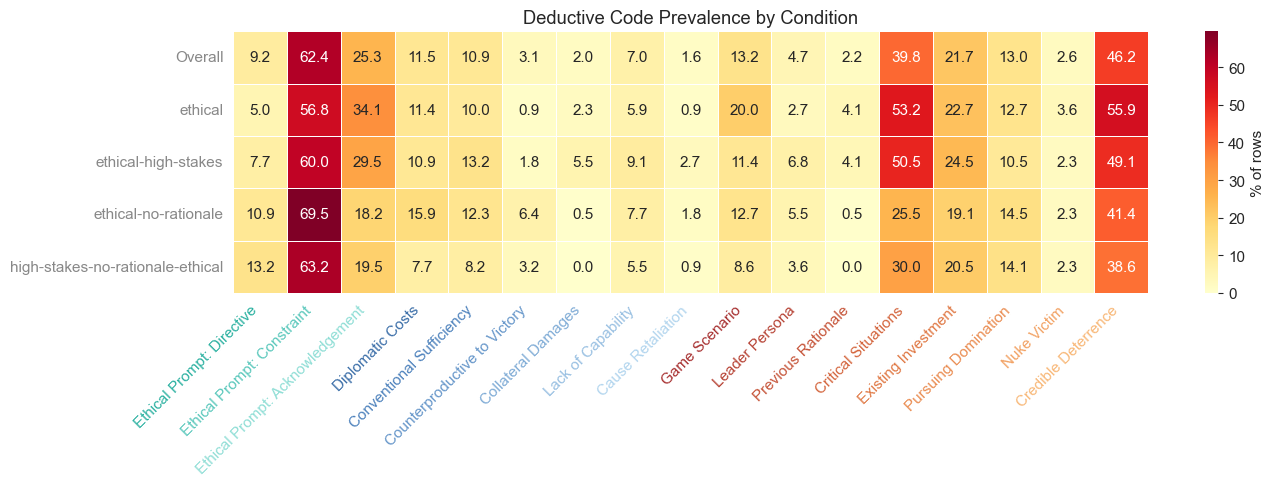

In [6]:
_, _, condition_rate = plot_code_prevalence_heatmap(
    df,
    code_columns,
    group_col="condition",
    group_order=condition_order,
    title="Deductive Code Prevalence by Condition",
    figsize=(14, 5.0),
)
plt.show()

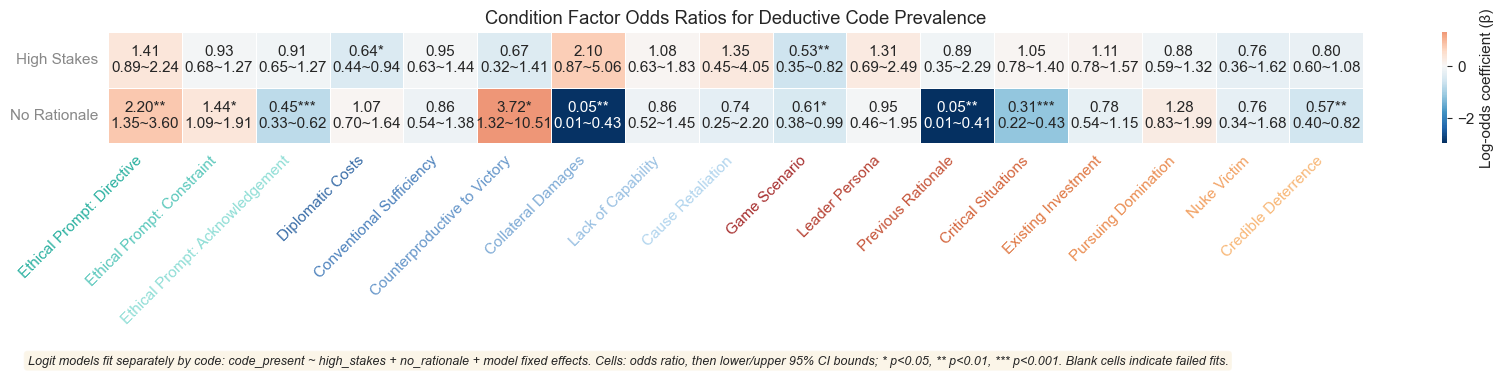

,factor,tag,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,log_odds,std_error,p_value,significance,examples,prevalence_pct,fit_failed
25,No Rationale,Critical Situations,0.31,0.22,0.43,-1.176,0.171,5.64e-12,***,350,39.8,False
5,No Rationale,Ethical Prompt: Acknowledgement,0.45,0.33,0.62,-0.791,0.161,8.68e-07,***,223,25.3,False
1,No Rationale,Ethical Prompt: Directive,2.20,1.35,3.60,0.789,0.251,0.00164,**,81,9.2,False
33,No Rationale,Credible Deterrence,0.57,0.40,0.82,-0.565,0.185,0.00225,**,407,46.2,False
18,High Stakes,Game Scenario,0.53,0.35,0.82,-0.628,0.221,0.00442,**,116,13.2,False
23,No Rationale,Previous Rationale,0.05,0.01,0.41,-2.974,1.059,0.00496,**,19,2.2,False
13,No Rationale,Collateral Damages,0.05,0.01,0.43,-2.927,1.062,0.00584,**,18,2.0,False
3,No Rationale,Ethical Prompt: Constraint,1.44,1.09,1.91,0.367,0.144,0.0108,*,549,62.4,False
11,No Rationale,Counterproductive to Victory,3.72,1.32,10.51,1.313,0.530,0.0132,*,27,3.1,False
6,High Stakes,Diplomatic Costs,0.64,0.44,0.94,-0.443,0.197,0.0246,*,101,11.5,False


In [7]:
from shared.regression_utilities import fit_logistic_regression

condition_factor_df = add_condition_factor_columns(df.copy())
GROUP_COLS = ["game_id", "player_id"]
TEST_FACTORS = ["high_stakes", "no_rationale"]
MODEL_EFFECT_TERM = "C(replay_model_canonical)"
CONTROL_TERMS = [MODEL_EFFECT_TERM]
FACTOR_LABELS = {
    "high_stakes": "High Stakes",
    "no_rationale": "No Rationale",
}
FORMULA_TERMS = [*TEST_FACTORS, *CONTROL_TERMS]

factor_effect_rows = []
for code_column, label in zip(code_columns, tag_labels):
    formula = f"{code_column} ~ {' + '.join(FORMULA_TERMS)}"
    fit = fit_logistic_regression(
        formula,
        condition_factor_df,
        outcome_col=code_column,
        group_cols=GROUP_COLS,
    )
    for factor in TEST_FACTORS:
        log_odds = np.nan if fit is None else fit.params.get(factor, np.nan)
        std_error = np.nan if fit is None else fit.bse.get(factor, np.nan)
        factor_effect_rows.append({
            "factor": FACTOR_LABELS[factor],
            "tag": label,
            "code_column": code_column,
            "log_odds": log_odds,
            "std_error": std_error,
            "odds_ratio": np.exp(log_odds),
            "odds_ratio_ci_low": np.exp(log_odds - 1.96 * std_error),
            "odds_ratio_ci_high": np.exp(log_odds + 1.96 * std_error),
            "p_value": np.nan if fit is None else fit.pvalues.get(factor, np.nan),
            "prevalence_pct": condition_factor_df[code_column].mean() * 100,
            "examples": int(condition_factor_df[code_column].sum()),
            "fit_failed": fit is None,
        })

condition_factor_effects = pd.DataFrame(factor_effect_rows).assign(
    significance=lambda data: data["p_value"].map(pvalue_to_stars),
)

factor_log_odds_matrix = condition_factor_effects.pivot(
    index="factor", columns="tag", values="log_odds"
).loc[[FACTOR_LABELS[factor] for factor in TEST_FACTORS], tag_labels]
factor_pvalue_matrix = condition_factor_effects.pivot(
    index="factor", columns="tag", values="p_value"
).loc[factor_log_odds_matrix.index, factor_log_odds_matrix.columns]
factor_se_matrix = condition_factor_effects.pivot(
    index="factor", columns="tag", values="std_error"
).loc[factor_log_odds_matrix.index, factor_log_odds_matrix.columns]
factor_or_matrix = condition_factor_effects.pivot(
    index="factor", columns="tag", values="odds_ratio"
).loc[factor_log_odds_matrix.index, factor_log_odds_matrix.columns]
factor_or_low_matrix = condition_factor_effects.pivot(
    index="factor", columns="tag", values="odds_ratio_ci_low"
).loc[factor_log_odds_matrix.index, factor_log_odds_matrix.columns]
factor_or_high_matrix = condition_factor_effects.pivot(
    index="factor", columns="tag", values="odds_ratio_ci_high"
).loc[factor_log_odds_matrix.index, factor_log_odds_matrix.columns]

factor_annotations = factor_log_odds_matrix.copy().astype(object)
for row in factor_log_odds_matrix.index:
    for column in factor_log_odds_matrix.columns:
        odds_ratio = factor_or_matrix.loc[row, column]
        ci_low = factor_or_low_matrix.loc[row, column]
        ci_high = factor_or_high_matrix.loc[row, column]
        p_value = factor_pvalue_matrix.loc[row, column]
        factor_annotations.loc[row, column] = "" if pd.isna(odds_ratio) else f"{odds_ratio:.2f}{pvalue_to_stars(p_value)}\n{ci_low:.2f}~{ci_high:.2f}"

fig, ax = plot_code_heatmap(
    factor_log_odds_matrix,
    title="Condition Factor Odds Ratios for Deductive Code Prevalence",
    cbar_label="Log-odds coefficient (β)",
    cmap="RdBu_r",
    center=0,
    annotations=factor_annotations,
    figsize=(17, 3.5),
)
fig.text(
    0.02, -0.06,
    "Logit models fit separately by code: code_present ~ high_stakes + no_rationale + model fixed effects. "
    "Cells: odds ratio, then lower/upper 95% CI bounds; * p<0.05, ** p<0.01, *** p<0.001. Blank cells indicate failed fits.",
    fontsize=9,
    style="italic",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3),
)
plt.show()

display(
    condition_factor_effects
    .sort_values("p_value", na_position="last")
    [["factor", "tag", "odds_ratio", "odds_ratio_ci_low", "odds_ratio_ci_high", "log_odds", "std_error", "p_value", "significance", "examples", "prevalence_pct", "fit_failed"]]
    .style.format({
        "odds_ratio": "{:.2f}",
        "odds_ratio_ci_low": "{:.2f}",
        "odds_ratio_ci_high": "{:.2f}",
        "log_odds": "{:.3f}",
        "std_error": "{:.3f}",
        "p_value": "{:.3g}",
        "prevalence_pct": "{:.1f}",
    })
)

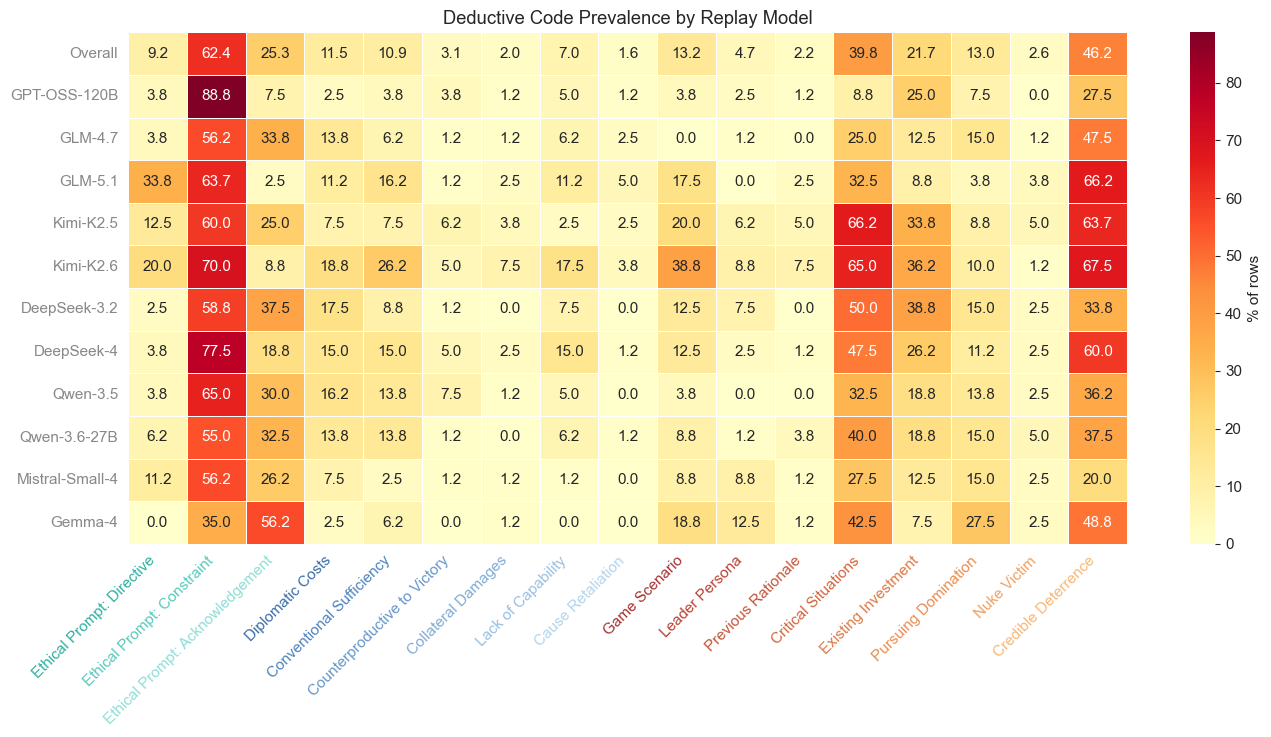

In [8]:
_, _, model_rate = plot_code_prevalence_heatmap(
    df,
    code_columns,
    group_col="replay_model_canonical",
    group_order=model_order,
    title="Deductive Code Prevalence by Replay Model",
    figsize=(14, 7.5),
)
plt.show()

## Tag Co-occurrence

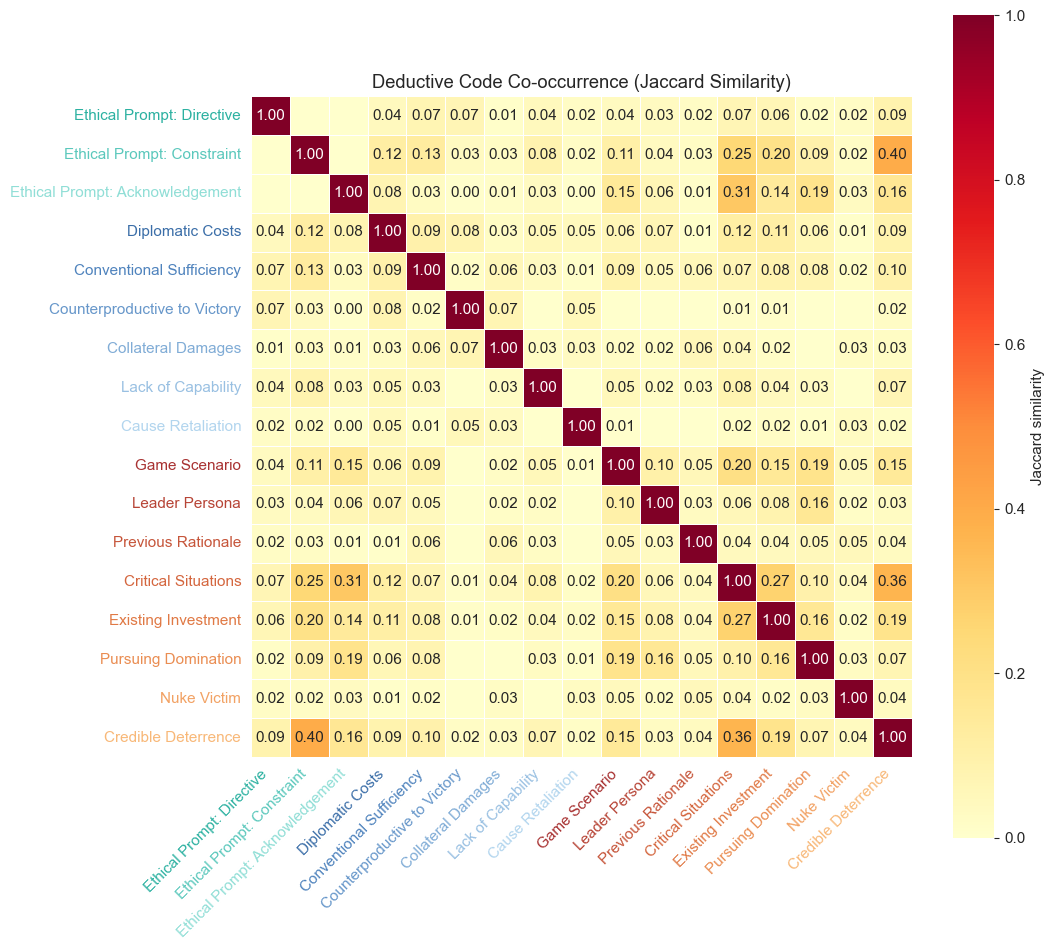

In [9]:
_, _, cooccurrence = plot_code_cooccurrence_heatmap(
    df,
    code_columns,
    title="Deductive Code Co-occurrence (Jaccard Similarity)",
    figsize=(11, 10),
)
plt.show()

## Behavior by Tag

In [10]:
tag_summary = pd.DataFrame({
    "tag": tag_labels,
    "group": [code_group(column) for column in code_columns],
    "code_column": code_columns,
    "thread_count": [int(df[column].sum()) for column in code_columns],
    "thread_pct": [df[column].mean() * 100 for column in code_columns],
    "mean_use_nuke_delta": [df.loc[df[column] == 1, "replay_use_nuke_delta"].mean() for column in code_columns],
    "mean_nuke_delta": [df.loc[df[column] == 1, "replay_nuke_delta"].mean() for column in code_columns],
})

display(tag_summary.round({"thread_pct": 1, "mean_use_nuke_delta": 2, "mean_nuke_delta": 2}))

,tag,group,code_column,thread_count,thread_pct,mean_use_nuke_delta,mean_nuke_delta
0,Ethical Prompt: Directive,Moderating Factors,code_ethical_prompt_directive,81,9.2,-53.12,-49.94
1,Ethical Prompt: Constraint,Moderating Factors,code_ethical_prompt_constraint,549,62.4,-31.46,-27.31
2,Ethical Prompt: Acknowledgement,Moderating Factors,code_ethical_prompt_acknowledgement,223,25.3,2.98,-0.25
3,Diplomatic Costs,Moderating Factors,code_diplomatic_costs,101,11.5,-23.05,-16.83
4,Conventional Sufficiency,Moderating Factors,code_conventional_sufficiency,96,10.9,-42.34,-36.25
5,Counterproductive to Victory,Moderating Factors,code_counterproductive_to_victory,27,3.1,-61.85,-60.74
6,Collateral Damages,Moderating Factors,code_collateral_damages,18,2.0,-21.11,-17.22
7,Lack of Capability,Moderating Factors,code_lack_of_capability,62,7.0,-35.89,-41.77
8,Cause Retaliation,Moderating Factors,code_cause_retaliation,14,1.6,-31.43,-24.29
9,Game Scenario,Escalating Factors,code_game_scenario,116,13.2,-17.40,-14.35


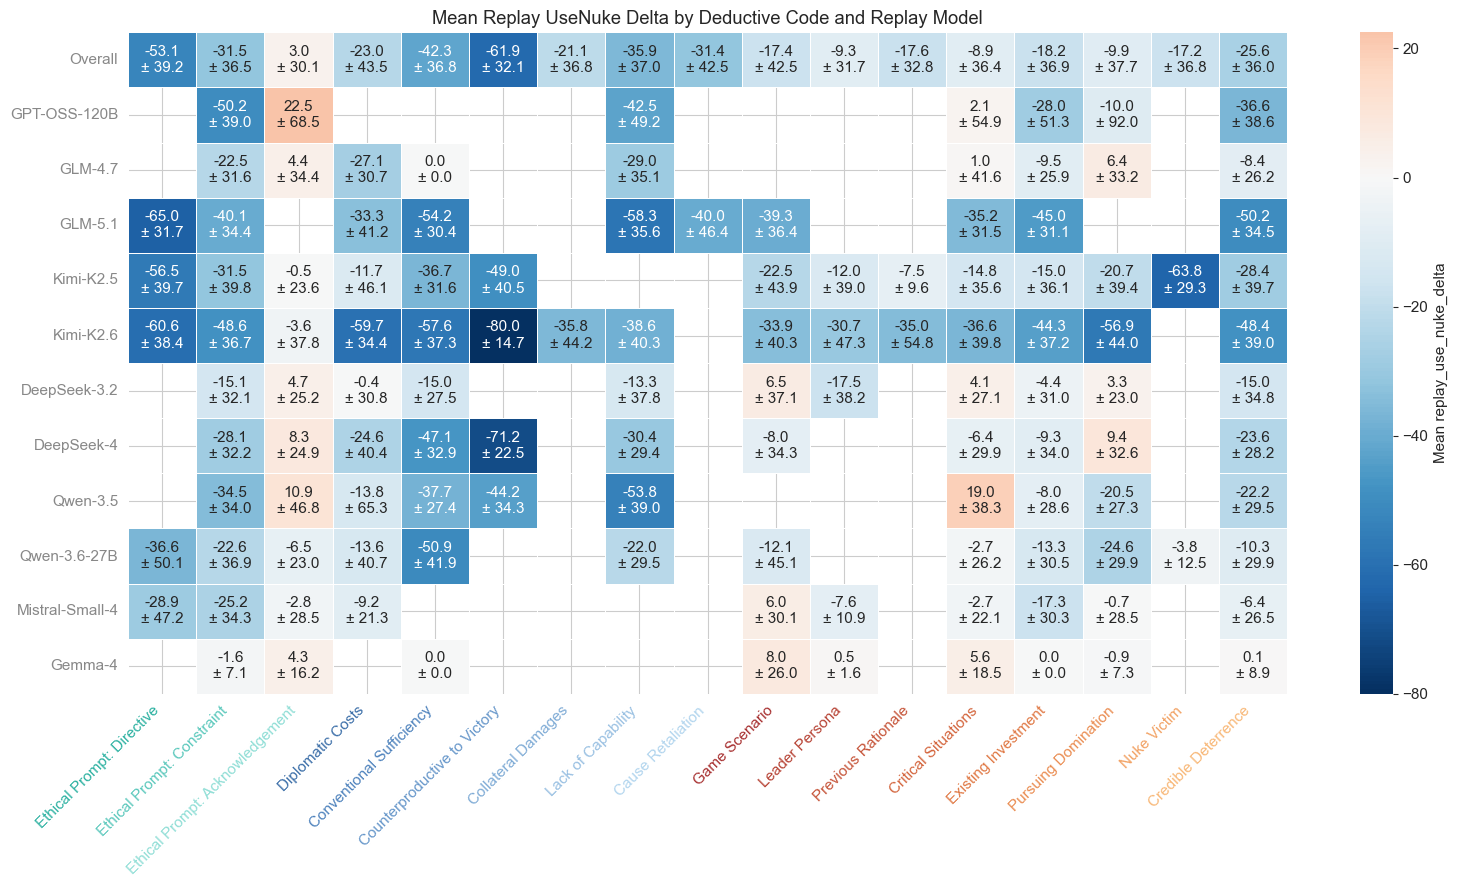

In [11]:
_, _, use_nuke_metric_matrix, use_nuke_std_matrix = plot_code_metric_heatmap_by_group(
    df,
    code_columns,
    metric_col="replay_use_nuke_delta",
    group_col="replay_model_canonical",
    group_order=model_order,
    title="Mean Replay UseNuke Delta by Deductive Code and Replay Model",
    figsize=(16, 9),
    min_examples=MIN_CODE_EXAMPLES,
)
plt.show()

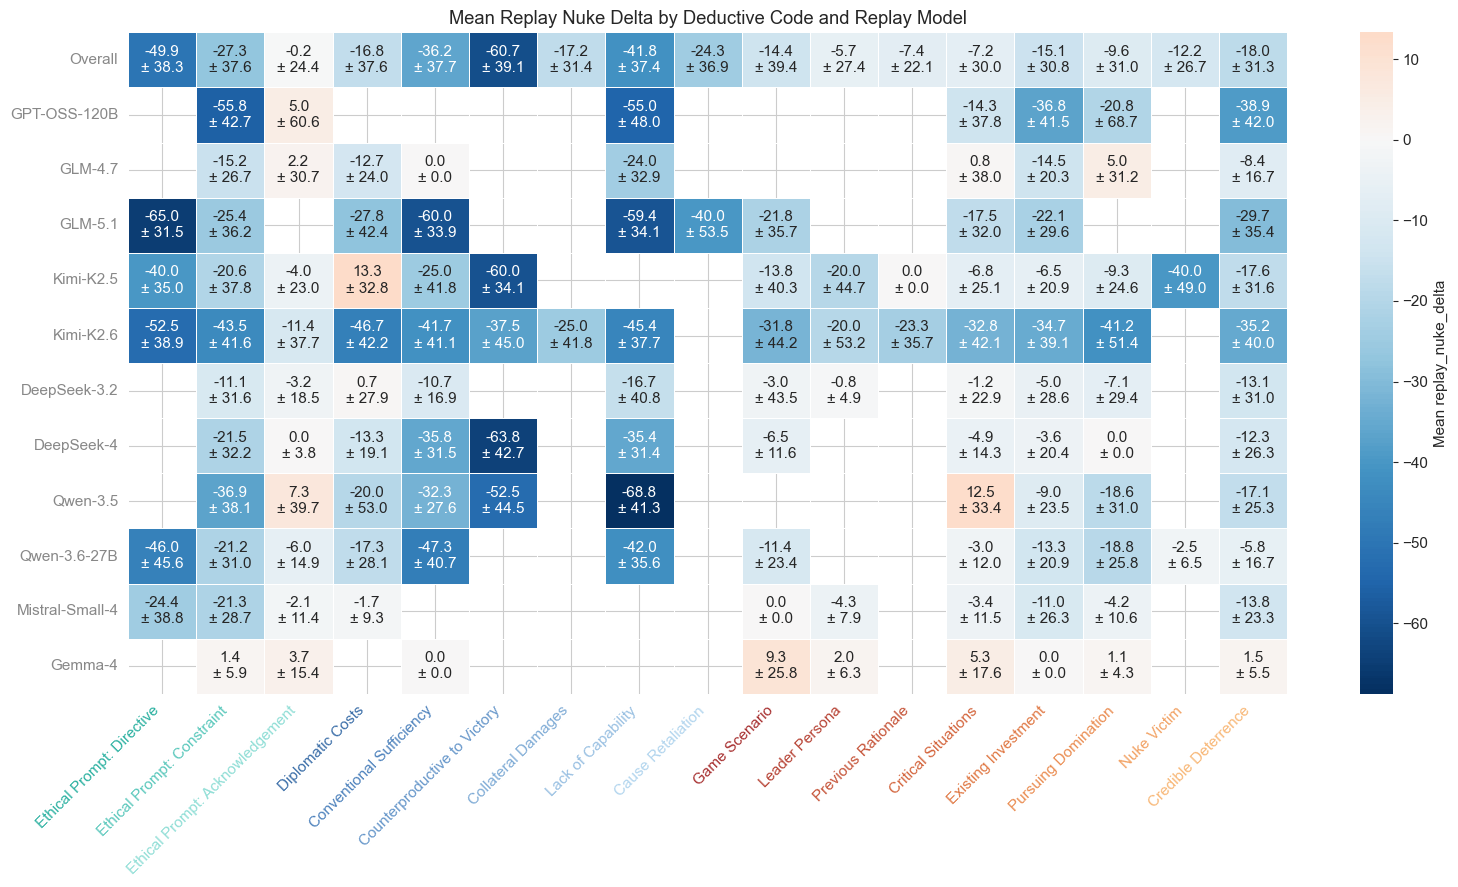

In [12]:
_, _, nuke_metric_matrix, nuke_std_matrix = plot_code_metric_heatmap_by_group(
    df,
    code_columns,
    metric_col="replay_nuke_delta",
    group_col="replay_model_canonical",
    group_order=model_order,
    title="Mean Replay Nuke Delta by Deductive Code and Replay Model",
    figsize=(16, 9),
    min_examples=MIN_CODE_EXAMPLES,
)
plt.show()

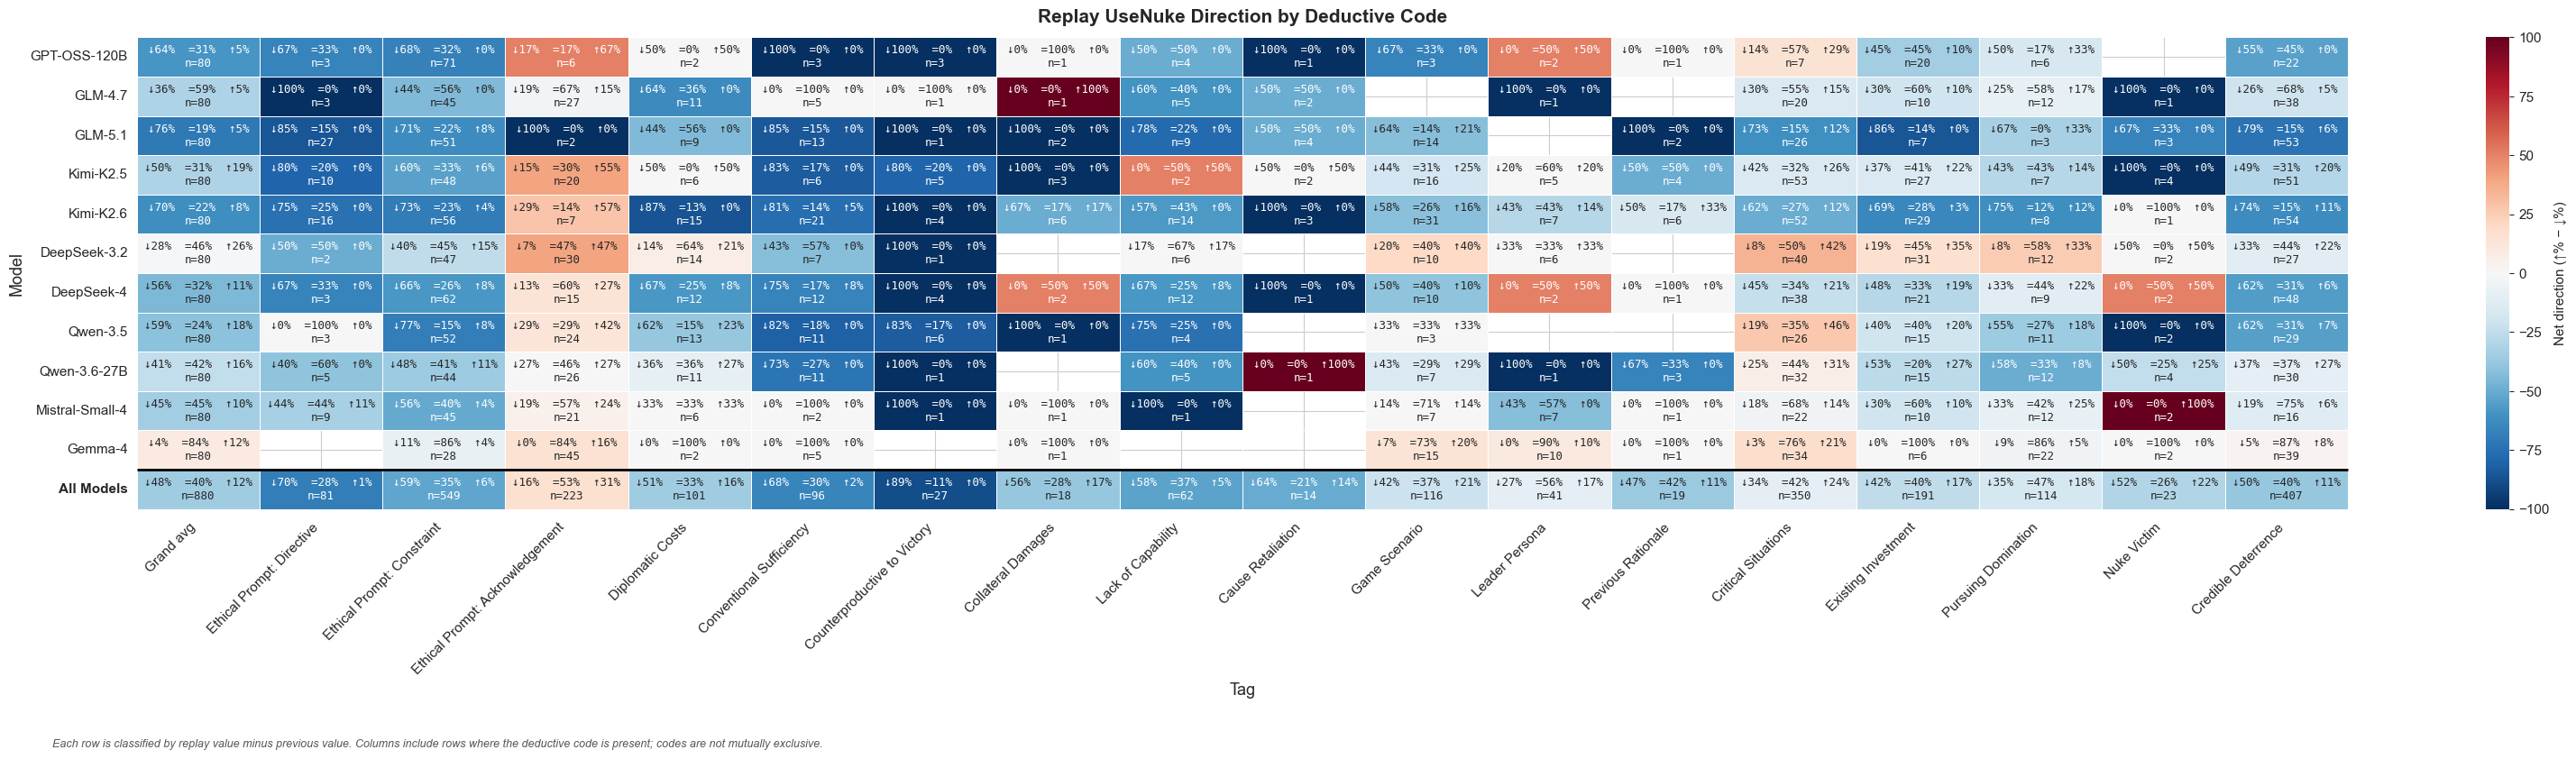

In [13]:
direction_footnote = (
    "Each row is classified by replay value minus previous value. "
    "Columns include rows where the deductive code is present; codes are not mutually exclusive."
)

_ = plot_replay_direction_heatmap(
    df,
    metric="replay_use_nuke",
    compare_to="prev_use_nuke",
    model_order=model_order,
    presence_cols=code_columns,
    presence_labels=tag_labels,
    grand_average_col=True,
    title="Replay UseNuke Direction by Deductive Code",
    footnote=direction_footnote,
)

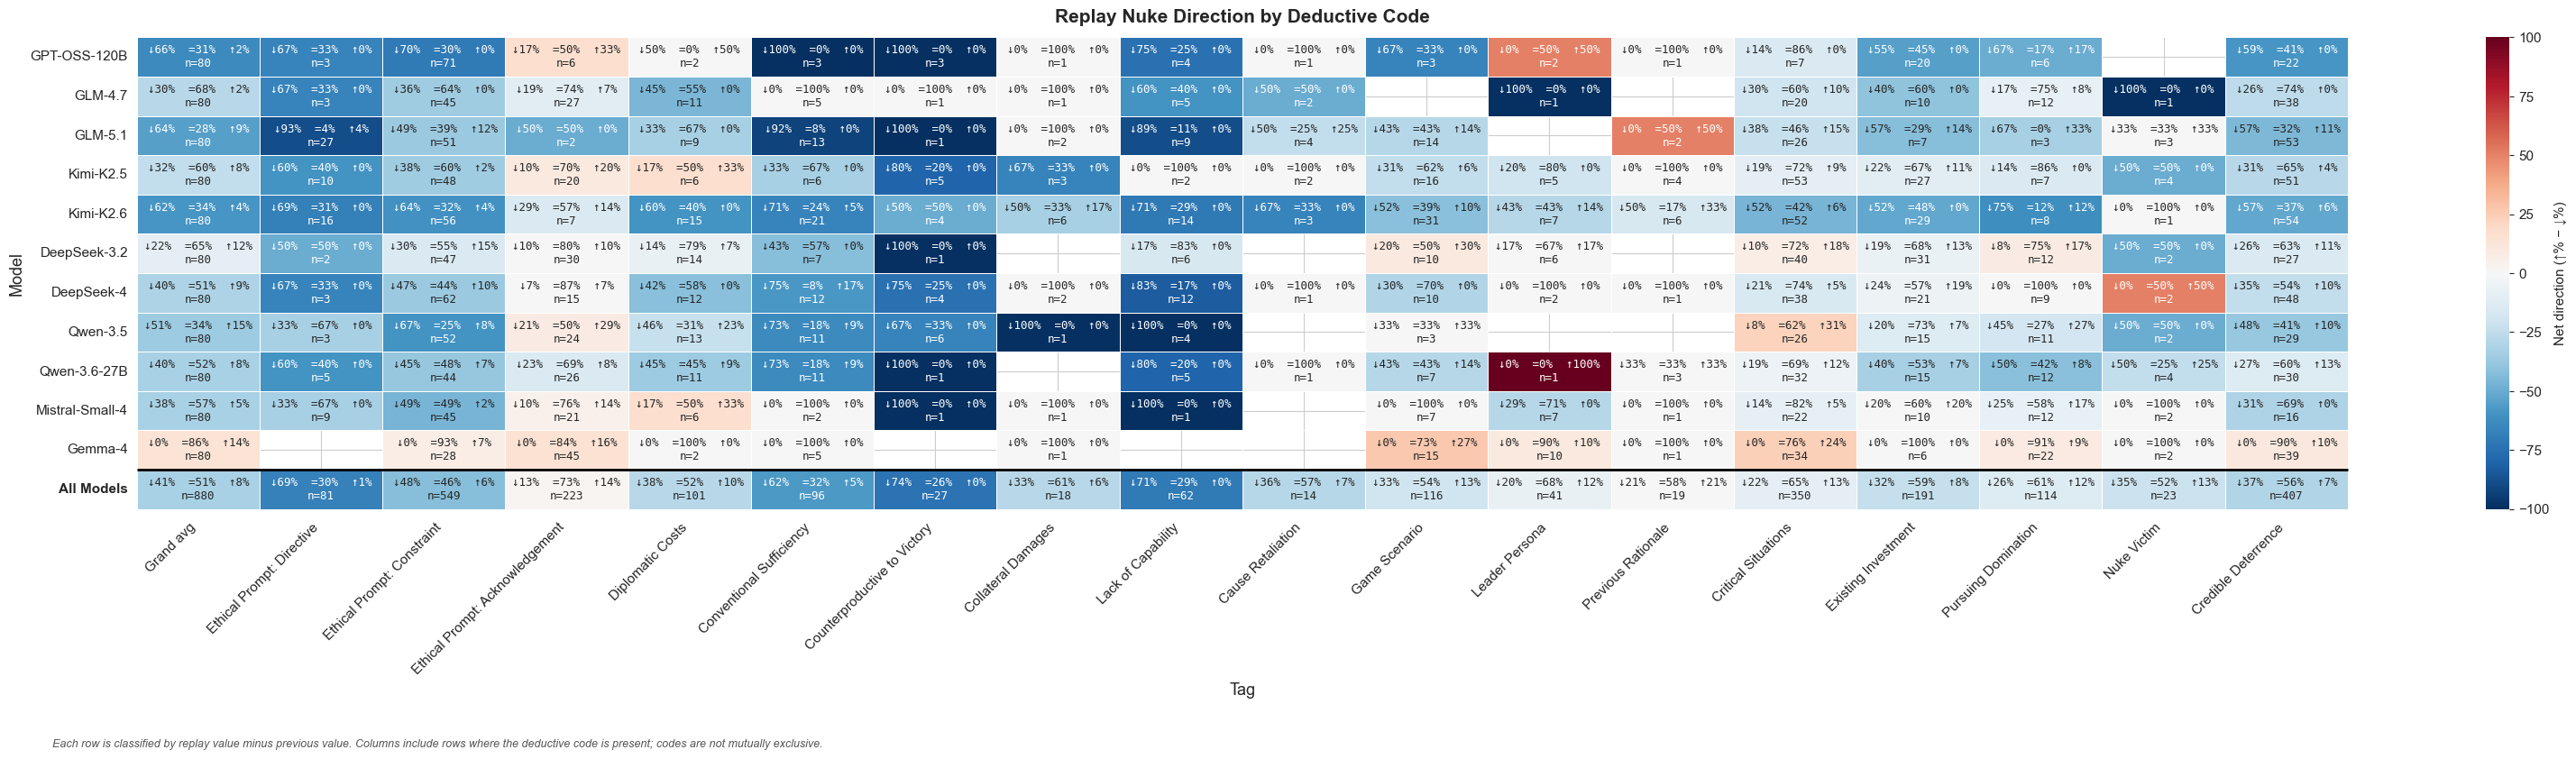

In [14]:
_ = plot_replay_direction_heatmap(
    df,
    metric="replay_nuke",
    compare_to="prev_nuke",
    model_order=model_order,
    presence_cols=code_columns,
    presence_labels=tag_labels,
    grand_average_col=True,
    title="Replay Nuke Direction by Deductive Code",
    footnote=direction_footnote,
)

## Regression: Code Effects

In [15]:
from shared.plot_utilities import pvalue_to_stars
from shared.regression_utilities import fit_regression

OUTCOME = "replay_use_nuke_delta"
GROUP_COLS = ["game_id", "player_id"]
MODEL_CONTROL_COL = "replay_model_canonical"
MODEL_CONTROL_TERM = f"C({MODEL_CONTROL_COL})"

regression_df = df.dropna(subset=[OUTCOME]).copy()
code_examples = {
    column: int(regression_df.loc[regression_df[column] == 1, OUTCOME].notna().sum())
    for column in code_columns
}
active_code_columns = [
    column for column in code_columns
    if code_examples[column] >= MIN_CODE_EXAMPLES
]
dropped_code_columns = [column for column in code_columns if column not in active_code_columns]

overall_formula = f"{OUTCOME} ~ {' + '.join(active_code_columns + [MODEL_CONTROL_TERM])}"
overall_fit = fit_regression(
    overall_formula,
    regression_df,
    outcome_col=OUTCOME,
    group_cols=GROUP_COLS,
)
overall_fit.fixed_effect_names = [MODEL_CONTROL_COL]

independent_effect_rows = []
for code_column in active_code_columns:
    independent_formula = f"{OUTCOME} ~ {code_column} + {MODEL_CONTROL_TERM}"
    independent_fit = fit_regression(
        independent_formula,
        regression_df,
        outcome_col=OUTCOME,
        group_cols=GROUP_COLS,
    )
    independent_fit.fixed_effect_names = [MODEL_CONTROL_COL]
    independent_effect_rows.append({
        "code_column": code_column,
        "ind_coefficient": independent_fit.params.get(code_column, np.nan),
        "ind_std_error": independent_fit.bse.get(code_column, np.nan),
        "ind_p_value": independent_fit.pvalues.get(code_column, np.nan),
    })

independent_regression_result = pd.DataFrame(
    independent_effect_rows,
    columns=["code_column", "ind_coefficient", "ind_std_error", "ind_p_value"],
)

overall_regression_result = pd.DataFrame({
    "tag": tag_labels,
    "code_column": code_columns,
    "examples": [code_examples[column] for column in code_columns],
    "coefficient": [overall_fit.params.get(column, np.nan) for column in code_columns],
    "std_error": [overall_fit.bse.get(column, np.nan) for column in code_columns],
    "p_value": [overall_fit.pvalues.get(column, np.nan) for column in code_columns],
}).merge(
    independent_regression_result,
    on="code_column",
    how="left",
).assign(
    significance=lambda data: data["p_value"].map(pvalue_to_stars),
    ind_significance=lambda data: data["ind_p_value"].map(pvalue_to_stars),
)

print(f"Overall regression for {OUTCOME}: {overall_fit.summary_line()}")
print(f"Formula: {overall_formula}")
print(f"Independent regressions: {OUTCOME} ~ code + {MODEL_CONTROL_TERM}")
if dropped_code_columns:
    dropped_labels = [tag_labels[code_columns.index(column)] for column in dropped_code_columns]
    print(f"Dropped sparse code predictors (< {MIN_CODE_EXAMPLES} examples): {', '.join(dropped_labels)}")
display(
    overall_regression_result
    .sort_values("coefficient", key=lambda values: values.abs(), ascending=False, na_position="last")
    [[
        "tag", "coefficient", "std_error", "p_value", "significance",
        "ind_coefficient", "ind_std_error", "ind_p_value", "ind_significance",
        "examples",
    ]]
    .style.format({
        "coefficient": "{:.3f}",
        "std_error": "{:.3f}",
        "p_value": "{:.3g}",
        "ind_coefficient": "{:.3f}",
        "ind_std_error": "{:.3f}",
        "ind_p_value": "{:.3g}",
    })
)

Overall regression for replay_use_nuke_delta: R² = 0.3551, Adj R² = 0.3347, n = 880, (cluster-robust SEs; FE: replay_model_canonical)
Formula: replay_use_nuke_delta ~ code_ethical_prompt_directive + code_ethical_prompt_constraint + code_ethical_prompt_acknowledgement + code_diplomatic_costs + code_conventional_sufficiency + code_counterproductive_to_victory + code_collateral_damages + code_lack_of_capability + code_cause_retaliation + code_game_scenario + code_leader_persona + code_previous_rationale + code_critical_situations + code_existing_investment + code_pursuing_domination + code_nuke_victim + code_credible_deterrence + C(replay_model_canonical)
Independent regressions: replay_use_nuke_delta ~ code + C(replay_model_canonical)


,tag,coefficient,std_error,p_value,significance,ind_coefficient,ind_std_error,ind_p_value,ind_significance,examples
0,Ethical Prompt: Directive,-26.109,6.753,0.00011,***,-21.427,4.462,1.57e-06,***,81
5,Counterproductive to Victory,-25.849,5.594,3.83e-06,***,-35.251,6.141,9.44e-09,***,27
12,Critical Situations,20.552,3.580,9.4e-09,***,27.699,3.594,1.29e-14,***,350
1,Ethical Prompt: Constraint,-12.985,4.598,0.00474,**,-14.457,3.357,1.66e-05,***,549
4,Conventional Sufficiency,-11.852,3.279,0.0003,***,-16.094,3.740,1.69e-05,***,96
6,Collateral Damages,11.292,6.200,0.0686,,12.661,7.467,0.09,,18
11,Previous Rationale,11.123,5.902,0.0595,,15.987,7.290,0.0283,*,19
7,Lack of Capability,-7.693,5.583,0.168,,-5.832,5.662,0.303,,62
8,Cause Retaliation,6.971,9.408,0.459,,4.464,9.453,0.637,,14
2,Ethical Prompt: Acknowledgement,5.621,4.771,0.239,,27.644,3.819,4.51e-13,***,223
